# TableTalk: Premier League results

Everything Phase 1 produces, in one place:

1. **Current predictions**: title, top-four and relegation odds for the season in progress.
2. **Team ratings**: what the Dixon-Coles model thinks of each side.
3. **Match-level backtest**: past matches forecast one week at a time, scored against a baseline, plus calibration.
4. **Season-level backtest**: past seasons replayed from four checkpoints, zone forecasts scored against the final tables.
5. **Promoted teams**: the three strategies compared.

The two backtests take a few minutes the first time and are then cached in `data/processed/`. Delete `data/processed/*.pkl` to recompute them after changing the data or the model.
The same numbers are available from the command line: `python -m tabletalk simulate | ratings | evaluate | evaluate-seasons`.

In [1]:
import warnings

import numpy as np
import pandas as pd

from tabletalk.config import load_competition
from tabletalk.data import load_context_matches, load_matches
from tabletalk.evaluation.backtest import match_backtest, summarise_backtest, summarise_by_season
from tabletalk.evaluation.calibration import match_calibration
from tabletalk.evaluation.plots import plot_calibration, plot_zone_probabilities
from tabletalk.evaluation.season_backtest import favourite_record, season_backtest, season_calibration_by_phase
from tabletalk.model.promoted import fit_competition_model, promoted_teams
from tabletalk.paths import PROCESSED_DATA_DIR
from tabletalk.simulation import simulate_league

warnings.simplefilter('ignore', UserWarning)  # rho-bound notices on tiny early-season fits
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

config = load_competition('premier_league')
matches = load_matches(config)
context = load_context_matches(config)   # Championship results, for the model only

def cached(name, compute):
    """Load a slow result from data/processed/, computing and saving it the first time."""
    path = PROCESSED_DATA_DIR / f'{name}.pkl'
    if path.exists():
        return pd.read_pickle(path)
    value = compute()
    pd.to_pickle(value, path)
    return value

def as_percent(frame, columns):
    return frame.assign(**{c: (100 * frame[c]).round(1) for c in columns})

print(f'{config.name}: {len(matches):,} matches loaded, current season {config.current_season}')

Premier League: 6,460 matches loaded, current season 2026-27


## 1. Current predictions

The rest of the season, simulated 10,000 times from today's ratings. Teams are ordered by expected finishing position; probabilities are in %. Each figure carries about ±1 percentage point of simulation noise at 50%, less near 0 or 100.

In [2]:
result = simulate_league(config, matches, context)
summary = result.summary()
zone_ids = [zone.id for zone in config.zones]
current = as_percent(summary, zone_ids)[
    ['position_now', 'points_now', 'expected_points', 'points_p10', 'points_p90', *zone_ids]
].round(1)
current

,position_now,points_now,expected_points,points_p10,points_p90,title,top_four,top_five,top_half,relegation
team,,,,,,,,,,
Manchester City,1,15,81.6,73.0,90.0,61.1,99.3,99.8,100.0,0.0
Arsenal,2,12,78.3,70.0,87.0,35.0,98.2,99.3,100.0,0.0
Brighton & Hove Albion,3,10,65.8,57.0,75.0,2.3,65.1,77.7,97.7,0.0
Liverpool,6,9,62.9,54.0,72.0,0.9,46.3,62.2,95.1,0.0
Brentford,4,9,59.5,50.0,69.0,0.4,28.7,43.9,89.0,0.1
Leeds United,5,9,56.5,47.0,66.0,0.1,15.8,26.9,79.0,0.3
Manchester United,12,5,56.0,47.0,65.0,0.1,14.8,26.1,77.6,0.4
Newcastle United,9,8,53.6,45.0,63.0,0.0,7.8,15.2,64.7,0.8
Chelsea,10,7,53.6,44.0,63.0,0.0,8.1,15.1,63.4,1.0


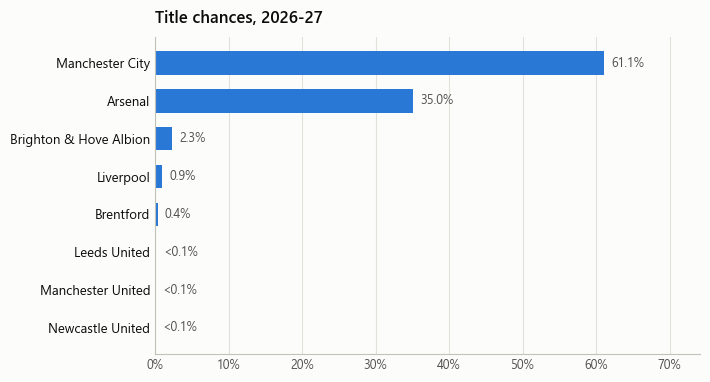

In [3]:
plot_zone_probabilities(summary, 'title', title=f'Title chances, {config.current_season}', top=8);

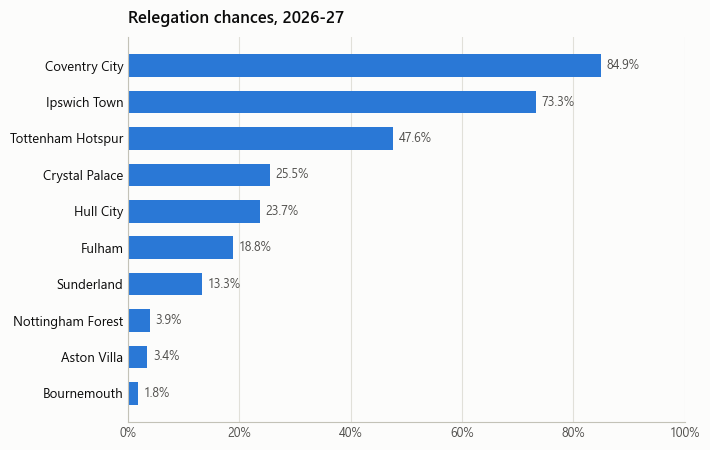

In [4]:
plot_zone_probabilities(summary, 'relegation', title=f'Relegation chances, {config.current_season}', top=10);

**Reading the average table.** `expected_points` is an average over 10,000 seasons, and averaging pulls everyone toward the middle: in any single simulated season *someone* runs hot, but it is a different team each time. The 10th-90th percentile range (`points_p10`, `points_p90`) is the better guide to realistic totals.

## 2. Team ratings

Each team's attack and defence on a log scale, re-centred on this season's league average. `attack_x` reads as "scores this many times an average team's goals", `concede_x` as "concedes this many times". The three promoted teams start from the promoted-team prior and have only a handful of matches of their own.

In [5]:
fit = fit_competition_model(config, matches, context)
season_teams = sorted(result.teams)
ratings = fit.model.ratings(season_teams)
ratings['attack'] -= ratings['attack'].mean()
ratings['defence'] -= ratings['defence'].mean()
ratings = ratings.assign(
    net=ratings['attack'] + ratings['defence'],
    attack_x=np.exp(ratings['attack']),
    concede_x=np.exp(-ratings['defence']),
).sort_values('net', ascending=False).reset_index(drop=True)
ratings.index += 1
print(fit.model.summary())
print('promoted this season:', ', '.join(fit.promoted))
ratings[['team', 'attack', 'defence', 'net', 'attack_x', 'concede_x', 'matches']].round(3)

Dixon-Coles fit as of 2026-09-21 (180-day half-life): 1863 matches (242 effective), 29 teams
  average team scores away : 1.179 goals
  home advantage           : +0.171 (x1.186 goals at home)
  rho (low-score coupling) : -0.1114
  division offsets         : none
  converged                : True (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
promoted this season: Coventry City, Hull City, Ipswich Town


,team,attack,defence,net,attack_x,concede_x,matches
1,Arsenal,0.235,0.536,0.771,1.265,0.585,186
2,Manchester City,0.404,0.308,0.712,1.498,0.735,186
3,Brighton & Hove Albion,0.248,0.080,0.328,1.282,0.923,186
4,Liverpool,0.215,0.073,0.287,1.239,0.930,187
5,Manchester United,0.198,-0.011,0.187,1.219,1.011,187
6,Brentford,0.137,0.049,0.186,1.147,0.952,187
7,Leeds United,-0.029,0.121,0.092,0.971,0.886,110
8,Bournemouth,0.067,0.013,0.080,1.069,0.987,157
9,Newcastle United,0.145,-0.122,0.022,1.156,1.130,186
10,Chelsea,0.162,-0.150,0.012,1.176,1.161,186


## 3. Match-level backtest

For every week of 12 completed seasons (2012-13 to 2025-26, leaving out the two COVID-affected seasons), fit the model on results *before* that week and forecast the week's matches. No forecast ever sees its own future. The baseline predicts the league's historical home/draw/away frequencies for every match. Lower is better for all three scores.

In [6]:
seasons = [s for s in config.seasons[2:-1] if s not in ('2019-20', '2020-21')]
match_predictions = cached(
    'premier_league_match_backtest',
    lambda: match_backtest(config, matches, context, seasons),
)
backtest_summary = summarise_backtest(match_predictions)
backtest_summary.loc[backtest_summary['group'] == 'all matches'].round(4)

,group,model,n,log_loss,brier,rps,vs_baseline_pct
0,all matches,none,4560,0.9722,0.5770,0.1984,8.7549
1,all matches,prior,4560,0.9680,0.5744,0.1972,9.1514
2,all matches,second_tier,4560,0.9697,0.5755,0.1978,8.9914
3,all matches,baseline,4560,1.0655,0.6441,0.2308,0.0000


In [7]:
summarise_by_season(match_predictions).round(4)

model,baseline,none,prior,second_tier
season,,,,
2012-13,1.0773,0.9795,0.9737,0.9807
2013-14,1.0561,0.9525,0.9406,0.9389
2014-15,1.0664,0.9936,0.9904,0.9923
2015-16,1.0880,1.0441,1.0348,1.0332
2016-17,1.0454,0.9418,0.9371,0.9388
2017-18,1.0667,0.9613,0.9546,0.9565
2018-19,1.0459,0.8981,0.8996,0.8965
2021-22,1.0712,0.9600,0.9564,0.9555
2022-23,1.0496,0.9942,0.9884,0.9813


### Calibration

Forecasts grouped by the probability they gave, against how often the outcome happened. On the diagonal is well calibrated; the vertical lines are 95% intervals. The panels underneath show how many forecasts fell in each range.

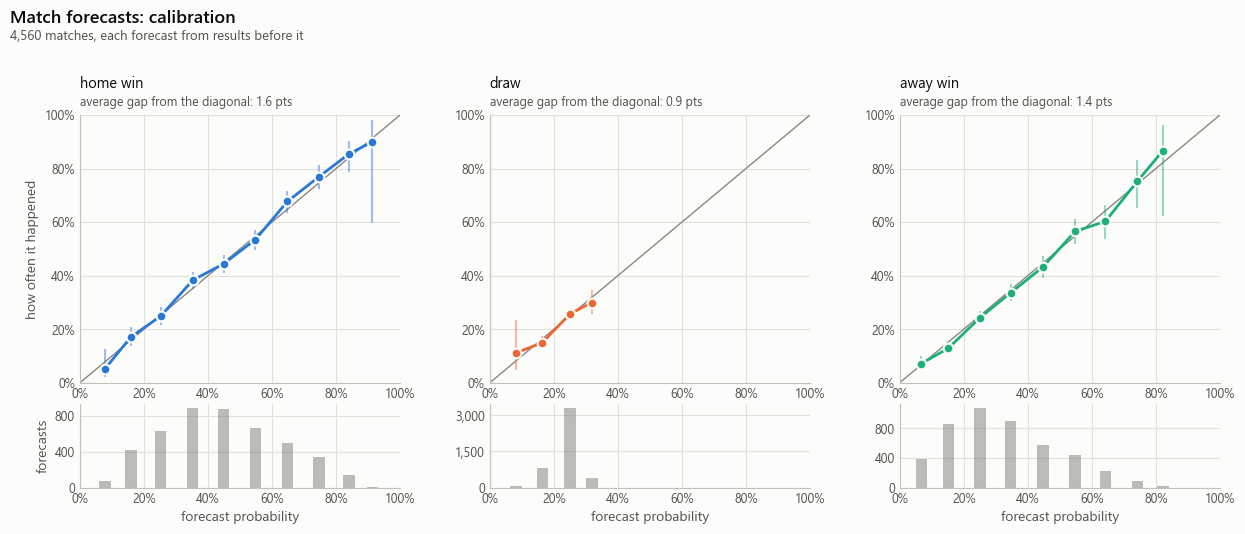

In [8]:
prior_predictions = match_predictions.loc[match_predictions['model'] == 'prior']
tables = match_calibration(prior_predictions)
plot_calibration(
    {'home win': tables['home'], 'draw': tables['draw'], 'away win': tables['away']},
    title='Match forecasts: calibration',
    subtitle=f'{len(prior_predictions):,} matches, each forecast from results before it',
);

In [9]:
as_percent(tables['home'], ['mean_forecast', 'observed', 'ci_low', 'ci_high', 'gap'])

,bin,n,mean_forecast,observed,ci_low,ci_high,gap
0,0%-10%,76,7.9,5.3,2.1,12.8,-2.6
1,10%-20%,421,15.9,17.1,13.8,21.0,1.2
2,20%-30%,634,25.2,24.9,21.7,28.4,-0.3
3,30%-40%,888,35.2,38.3,35.1,41.5,3.0
4,40%-50%,880,44.9,44.4,41.2,47.7,-0.4
5,50%-60%,666,54.8,53.5,49.7,57.2,-1.3
6,60%-70%,502,64.8,67.7,63.5,71.7,2.9
7,70%-80%,339,74.7,77.0,72.2,81.2,2.3
8,80%-90%,144,84.0,85.4,78.7,90.3,1.4
9,90%-100%,10,91.4,90.0,59.6,98.2,-1.4


When the model gave the home side 60-70%, they won about 68% of the time; across the bins the average gap from the diagonal is under two percentage points for every outcome.

The one thing the model cannot do is **pick out draws**: almost every draw forecast lies between 20% and 35%. Its draw forecasts are well calibrated but barely vary, which is a known property of Dixon-Coles: team strengths tell you who is likely to win, much less whether a match will be level.

## 4. Season-level backtest

The question the project exists for. Each of the 12 seasons is replayed from four checkpoints (pre-season, then after 25%, 50% and 75% of the matches): every later result is forgotten, the model is fitted on what was known then, and the rest of the season is simulated 5,000 times. The zone forecasts are scored against the real final table and two baselines:

- **uniform** knows nothing: a 1-in-20 title chance for everyone, 4-in-20 for the top four, and so on.
- **persistence** says the table as it stands will be the final table (pre-season: last season's table, promoted teams at the bottom). This is the naive pundit, and a hard baseline late in a season.

In [10]:
seasons_backtest = cached(
    'premier_league_season_backtest',
    lambda: season_backtest(config, matches, context, seasons, n_simulations=5_000),
)
zones = seasons_backtest.zone_summary()
order = zones['checkpoint'].unique()
skill = {
    baseline: zones.pivot(index='checkpoint', columns='zone', values=f'skill_vs_{baseline}_pct').loc[order, zone_ids]
    for baseline in ('uniform', 'persistence')
}
print('Brier-score skill vs uniform (% better; higher is better)')
skill['uniform'].round(1)

Brier-score skill vs uniform (% better; higher is better)


zone,title,top_four,top_five,top_half,relegation
checkpoint,,,,,
pre-season,25.5,39.5,52.1,37.8,25.6
25% played,48.0,58.6,65.5,51.6,42.8
50% played,59.2,81.7,85.7,66.2,54.7
75% played,67.8,83.2,85.7,73.3,75.2


In [11]:
print('Brier-score skill vs persistence (% better than "the table as it stands")')
skill['persistence'].round(1)

Brier-score skill vs persistence (% better than "the table as it stands")


zone,title,top_four,top_five,top_half,relegation
checkpoint,,,,,
pre-season,46.9,35.5,46.1,41.7,36.8
25% played,63.0,53.2,48.3,36.9,37.5
50% played,53.5,56.1,54.1,27.6,36.9
75% played,54.2,35.6,54.1,38.3,-26.4


In [12]:
print('Finishing position: ranked probability score (lower is better) and average error in places')
seasons_backtest.position_summary().round(3)

Finishing position: ranked probability score (lower is better) and average error in places


,checkpoint,n,rps_model,rps_uniform,rps_persistence,position_error_model,position_error_persistence
0,pre-season,240,0.106,0.175,0.171,2.849,3.250
1,25% played,240,0.084,0.175,0.142,2.287,2.692
2,50% played,240,0.063,0.175,0.106,1.707,2.008
3,75% played,240,0.046,0.175,0.074,1.290,1.400


In [13]:
print("How often the model's pre-season / in-season title favourite won (descriptive only)")
favourite_record(seasons_backtest.zones).round(3)

How often the model's pre-season / in-season title favourite won (descriptive only)


,checkpoint,seasons,favourite_won,mean_favourite_probability
0,pre-season,12,5,0.582
1,25% played,12,8,0.640
2,50% played,12,9,0.695
3,75% played,12,8,0.739


### Calibration of season forecasts

Pooling every checkpoint hides the main pattern, so forecasts made early (pre-season and 25% played) and later (50% and 75%) are shown separately.

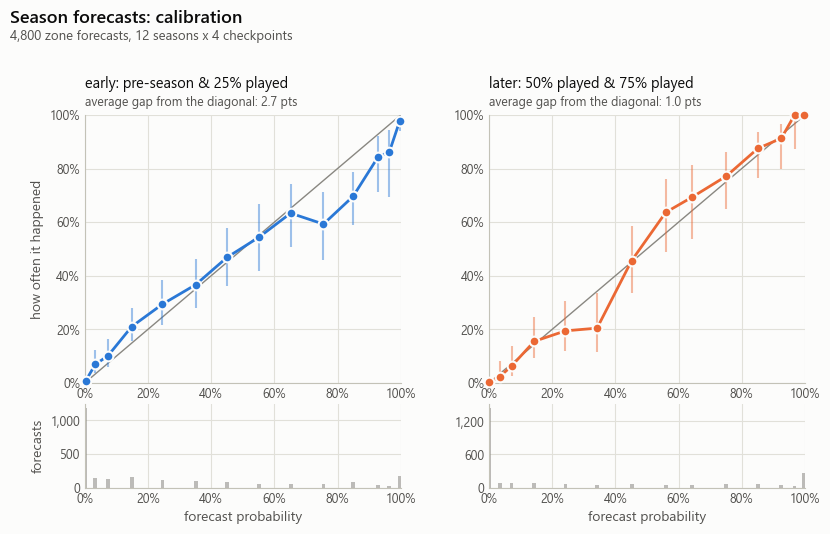

In [14]:
phases = season_calibration_by_phase(seasons_backtest.zones)
plot_calibration(
    phases,
    title='Season forecasts: calibration',
    subtitle=f'{len(seasons_backtest.zones):,} zone forecasts, {len(seasons)} seasons x 4 checkpoints',
);

In [15]:
confident = seasons_backtest.zones.loc[seasons_backtest.zones['p_model'].between(0.7, 0.99)]
print('Confident forecasts (70-99%): average forecast vs how often it happened, in %')
(100 * confident.groupby('checkpoint', sort=False)[['p_model', 'outcome']].mean()).round(1)

Confident forecasts (70-99%): average forecast vs how often it happened, in %


,p_model,outcome
checkpoint,,
pre-season,86.6,71.4
25% played,87.1,77.2
50% played,86.6,86.5
75% played,87.2,90.6


**Early in a season the model is over-confident; later it is not.** Forecasts of 70-99% made pre-season came true about 71% of the time against an average forecast of 87%; by mid-season forecast and outcome agree. Late in a season the opposite weakness shows up in the persistence comparison above: with a quarter of the season left, the bottom three usually stay there, and the model loses to "the table as it stands" by hedging on teams whose ratings still look respectable (Leicester 2022-23 were in the bottom three and given 21%; they went down).

Both come from the same simplification: each team's strength is fixed within a simulated season. Over a long horizon real strength drifts (transfers, injuries, managers), so early forecasts are too sure; late on, ratings partly built from last season lag a genuinely declining team that the table has already caught. The natural fix is to give ratings uncertainty that grows with the forecast horizon.

The pooled observations are not independent (the same team appears at four checkpoints, and exactly one team wins each title), so the intervals are narrower than they should be: read them as a guide rather than a test.

## 5. Promoted teams

Three ways to rate a team promoted this season, compared on the match-level backtest: `prior` (start from the average first-season rating of past promoted teams), `second_tier` (fit the Championship alongside), and `none` (no special handling).

In [16]:
backtest_summary.loc[backtest_summary['group'].str.contains('promoted')].round(4)

,group,model,n,log_loss,brier,rps,vs_baseline_pct
4,promoted team involved,none,1296,0.9319,0.5489,0.1887,11.7387
5,promoted team involved,prior,1296,0.9173,0.5400,0.1847,13.1169
6,promoted team involved,second_tier,1296,0.9302,0.5484,0.1885,11.8960
7,promoted team involved,baseline,1296,1.0558,0.6376,0.2312,0.0000
12,"early season, promoted team involved",none,340,0.9298,0.5476,0.1857,12.3747
13,"early season, promoted team involved",prior,340,0.9038,0.5309,0.1781,14.8274
14,"early season, promoted team involved",second_tier,340,0.9317,0.5480,0.1859,12.1953
15,"early season, promoted team involved",baseline,340,1.0611,0.6410,0.2296,0.0000


In [17]:
rows = []
for season in seasons:
    promoted = set(promoted_teams(matches, config.id, season) or [])
    in_season = match_predictions.loc[(match_predictions['season'] == season) & (match_predictions['model'] != 'baseline')]
    for side, other in (('home', 'away'), ('away', 'home')):
        mine = in_season.loc[in_season[f'{side}_team'].isin(promoted)]
        rows.append(pd.DataFrame({
            'model': mine['model'],
            'phase': np.where(mine[f'{side}_game_no'] <= 10, 'games 1-10', 'games 11-38'),
            'error': (mine[f'expected_{side}_goals'] - mine[f'expected_{other}_goals'])
                     - (mine[f'{side}_goals'].astype(float) - mine[f'{other}_goals'].astype(float)),
        }))
bias = pd.concat(rows).groupby(['phase', 'model'])['error'].agg(['size', 'mean', 'sem'])
bias['ci95'] = 1.96 * bias['sem']
print('Promoted teams: forecast minus actual goal difference per game (positive = over-rated)')
bias[['size', 'mean', 'ci95']].round(3)

Promoted teams: forecast minus actual goal difference per game (positive = over-rated)


size   mean   ci95
phase       model                          
games 1-10  none          360  0.232  0.170
            prior         360  0.146  0.163
            second_tier   360  0.392  0.166
games 11-38 none         1008 -0.027  0.099
            prior        1008 -0.036  0.098
            second_tier  1008  0.081  0.098

`prior` is the default: it scores best on the promoted-team matches and its early-season bias is the only one not distinguishable from zero. `second_tier` over-rates promoted teams because a club is promoted partly *because* its Championship results flattered it (the winner's curse).

## Known limitations

- The model sees only scorelines: no injuries, transfers, managerial changes, xG or fixture congestion.
- Strengths are fixed within a simulated season, which understates the spread of outcomes slightly.
- Home advantage and rho are single numbers per fit; both vary from season to season.
- Twelve seasons is a small sample for rare events: there are only twelve champions to predict.

The README covers each of these in more detail.